In [1]:
"""
Fragment 1 — Data Loading & Feature Extraction (Flattened Pixels)
==================================================================
SVM Mould/Fruit Multiclass Classification Pipeline

- Loads train, val and test data from disk
- Resizes all images to IMG_SIZE
- Flattens each image to a 1D feature vector
- Normalises pixel values to [0, 1]
- No augmentation applied to val or test
- Train data loaded from augmented folder
"""

import os
import numpy as np
from pathlib import Path
from PIL import Image
from sklearn.preprocessing import LabelEncoder

# ── Configuration ─────────────────────────────────────────────────────────────

DATA_DIR   = r"D:\Mold Studies\Mould Studies Multiclass"
AUG_DIR    = os.path.join(DATA_DIR, "augmented")
VALID_DIR  = os.path.join(DATA_DIR, "val")
TEST_DIR   = os.path.join(DATA_DIR, "test")

IMG_SIZE   = (32, 32)     # smaller than DL models — SVM cannot handle
                           # 224x224x3 = 150528 features efficiently
IMG_EXTS   = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}

# ── Step 1: Image loader ──────────────────────────────────────────────────────

def load_flat_dataset(folder: str, img_size: tuple) -> tuple:
    """
    Loads all images from a class-structured folder.
    Resizes, flattens and normalises each image.
    Returns X (n_samples, n_features) and y (n_samples,) as strings.
    """
    X, y = [], []

    folder_path = Path(folder)
    classes     = sorted([d.name for d in folder_path.iterdir() if d.is_dir()])

    for cls in classes:
        cls_path = folder_path / cls
        images   = [
            f for f in cls_path.iterdir()
            if f.suffix.lower() in IMG_EXTS
        ]

        for img_path in images:
            try:
                img = Image.open(img_path).convert("RGB")
                img = img.resize(img_size)
                arr = np.array(img, dtype=np.float32) / 255.0
                X.append(arr.flatten())
                y.append(cls)
            except Exception as e:
                print(f"  ⚠️  Skipped {img_path.name}: {e}")

    return np.array(X), np.array(y)

# ── Step 2: Load all three sets ───────────────────────────────────────────────

print("=" * 60)
print("  Fragment 1 — Loading & Flattening Images")
print("=" * 60)
print(f"  Image size    : {IMG_SIZE}")
print(f"  Features      : {IMG_SIZE[0] * IMG_SIZE[1] * 3}")
print("=" * 60)

print(f"\n  Loading train (augmented)...")
X_train_raw, y_train_raw = load_flat_dataset(AUG_DIR,   IMG_SIZE)
print(f"  ✓ Train : {X_train_raw.shape}")

print(f"\n  Loading val...")
X_val_raw,   y_val_raw   = load_flat_dataset(VALID_DIR, IMG_SIZE)
print(f"  ✓ Val   : {X_val_raw.shape}")

print(f"\n  Loading test...")
X_test_raw,  y_test_raw  = load_flat_dataset(TEST_DIR,  IMG_SIZE)
print(f"  ✓ Test  : {X_test_raw.shape}")

# ── Step 3: Encode labels ─────────────────────────────────────────────────────

label_encoder = LabelEncoder()
label_encoder.fit(y_train_raw)

y_train = label_encoder.transform(y_train_raw)
y_val   = label_encoder.transform(y_val_raw)
y_test  = label_encoder.transform(y_test_raw)

CLASS_NAMES = list(label_encoder.classes_)
NUM_CLASSES = len(CLASS_NAMES)

# ── Step 4: Summary ───────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("  Fragment 1 — Data Ready")
print("=" * 60)
print(f"  Architecture  : SVM (flattened pixels)")
print(f"  Train samples : {X_train_raw.shape[0]}")
print(f"  Val samples   : {X_val_raw.shape[0]}")
print(f"  Test samples  : {X_test_raw.shape[0]}")
print(f"  Features      : {X_train_raw.shape[1]}")
print(f"  Classes ({NUM_CLASSES})  : {CLASS_NAMES}")
print("=" * 60)

print("\n  ✓ Fragment 1 complete.")
print("     Proceed to Fragment 2 — SVM Training & 5-Run Analysis.\n")

  Fragment 1 — Loading & Flattening Images
  Image size    : (32, 32)
  Features      : 3072

  Loading train (augmented)...
  ✓ Train : (8833, 3072)

  Loading val...
  ✓ Val   : (644, 3072)

  Loading test...
  ✓ Test  : (658, 3072)

  Fragment 1 — Data Ready
  Architecture  : SVM (flattened pixels)
  Train samples : 8833
  Val samples   : 644
  Test samples  : 658
  Features      : 3072
  Classes (11)  : ['Blackberry', 'Blueberry', 'Carrots', 'Cheese', 'Cream Cheese', 'Mixed Bread', 'Onion', 'Orange', 'Raspberry', 'Toast', 'Tomatoes']

  ✓ Fragment 1 complete.
     Proceed to Fragment 2 — SVM Training & 5-Run Analysis.



  Fragment 2 — SVM 5-Run Training
  Kernel       : linear
  C            : 1.0
  Gamma        : scale
  Seeds        : [27, 42, 99, 123, 256]
  Features     : 3072

  RUN 1 / 5  —  SVM (Flattened Pixels)
  Seed : 27

  Training SVM...
  ✓ Training complete

  Run 1 Results
    Accuracy     : 0.9453
    Precision    : 0.9440
    Recall       : 0.9566
    Specificity  : 0.9945
    F1 Score     : 0.9485
    Mean AUC     : 0.9981


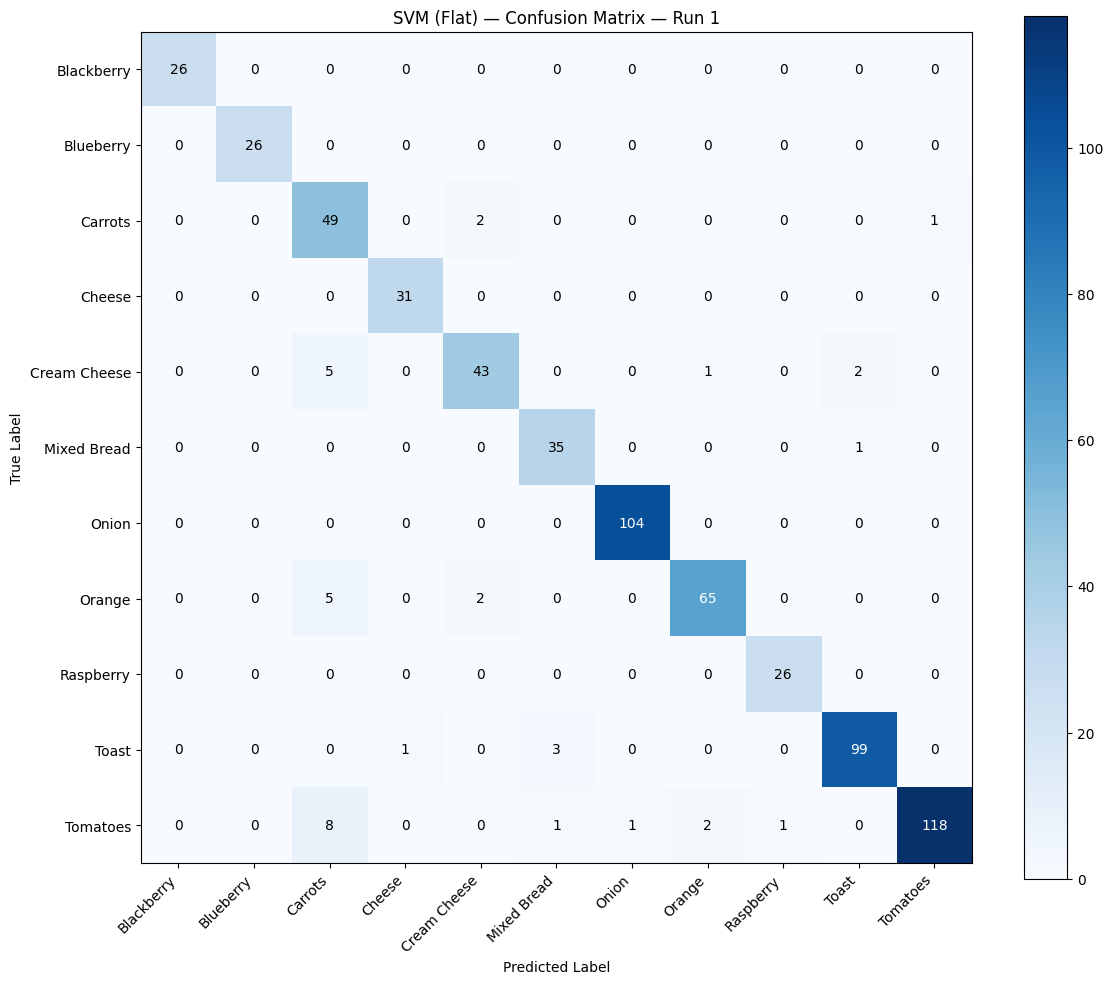

  Saved: D:\Mold Studies\Models\plots\svm_flat\svm_flat_confusion_matrix_run1.png


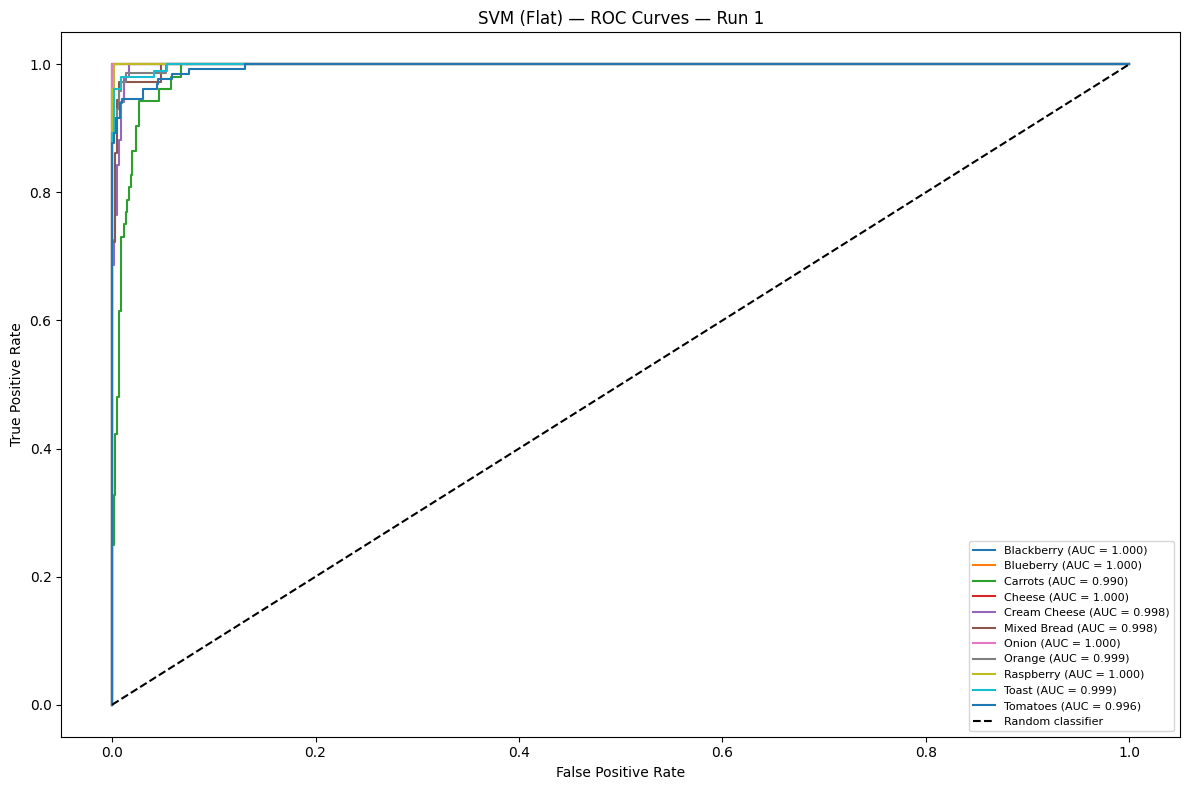

  Saved: D:\Mold Studies\Models\plots\svm_flat\svm_flat_roc_curves_run1.png


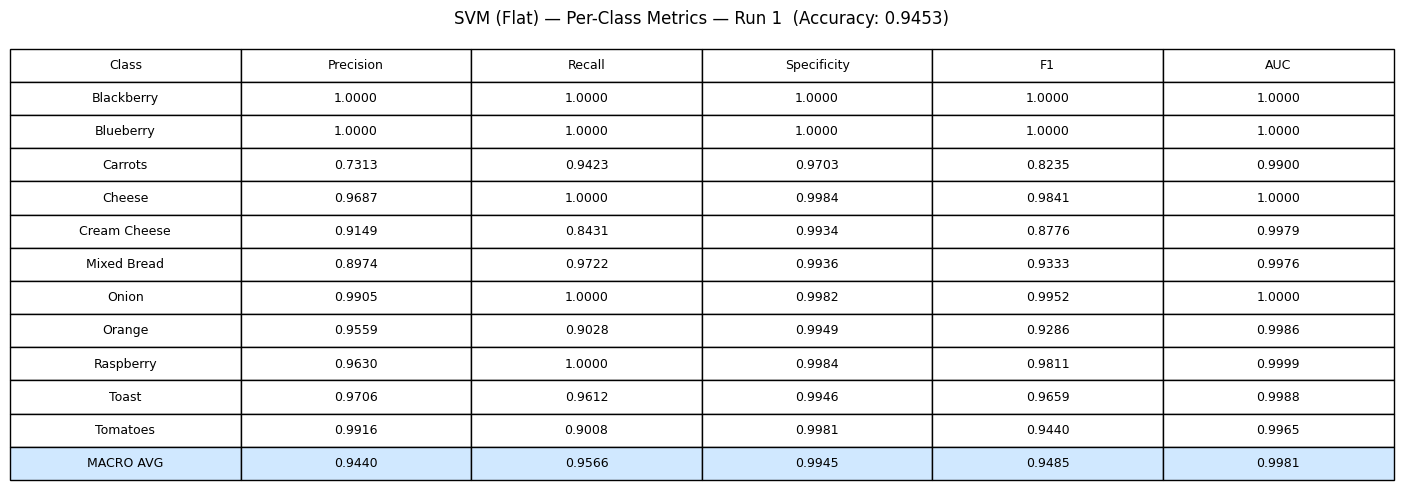

  Saved: D:\Mold Studies\Models\plots\svm_flat\svm_flat_metrics_table_run1.png

  RUN 2 / 5  —  SVM (Flattened Pixels)
  Seed : 42

  Training SVM...
  ✓ Training complete

  Run 2 Results
    Accuracy     : 0.9453
    Precision    : 0.9440
    Recall       : 0.9566
    Specificity  : 0.9945
    F1 Score     : 0.9485
    Mean AUC     : 0.9981


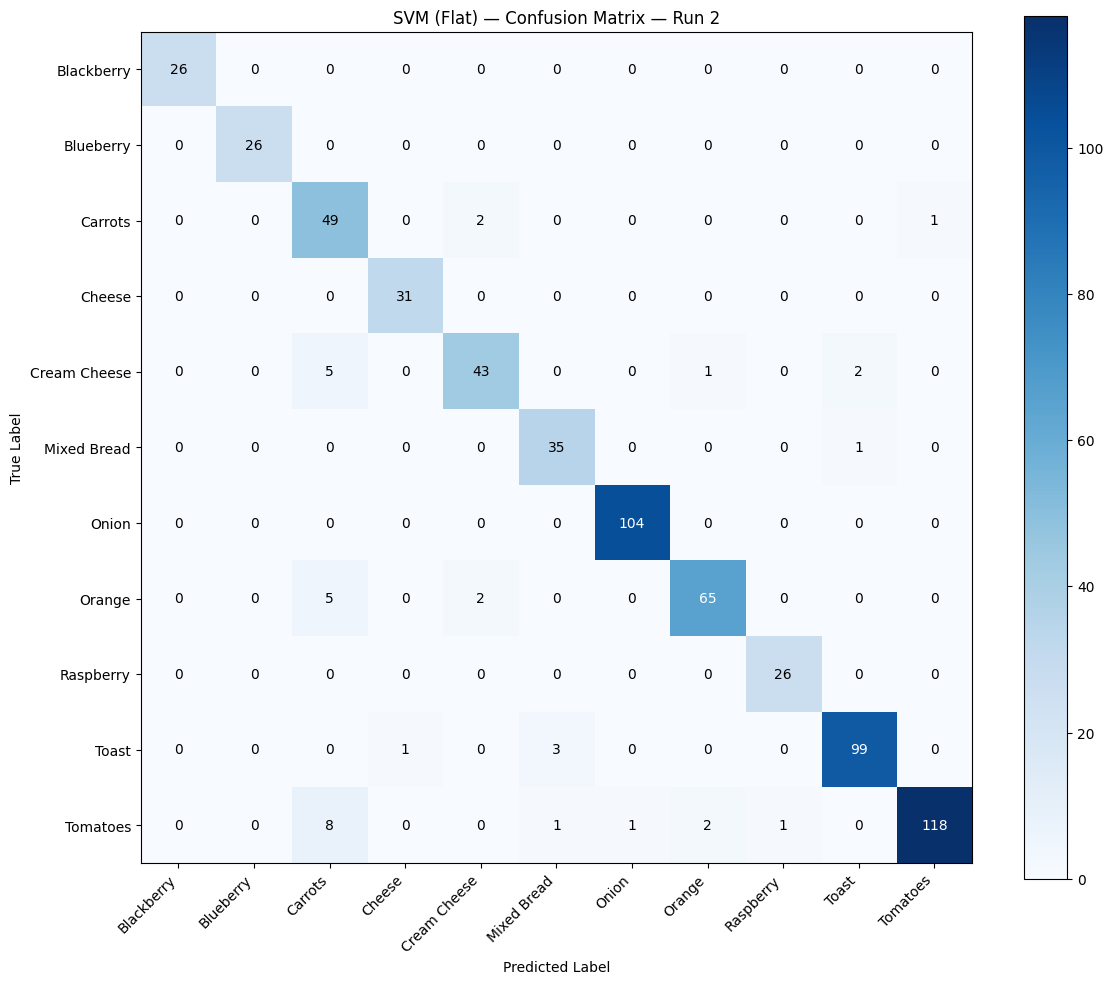

  Saved: D:\Mold Studies\Models\plots\svm_flat\svm_flat_confusion_matrix_run2.png


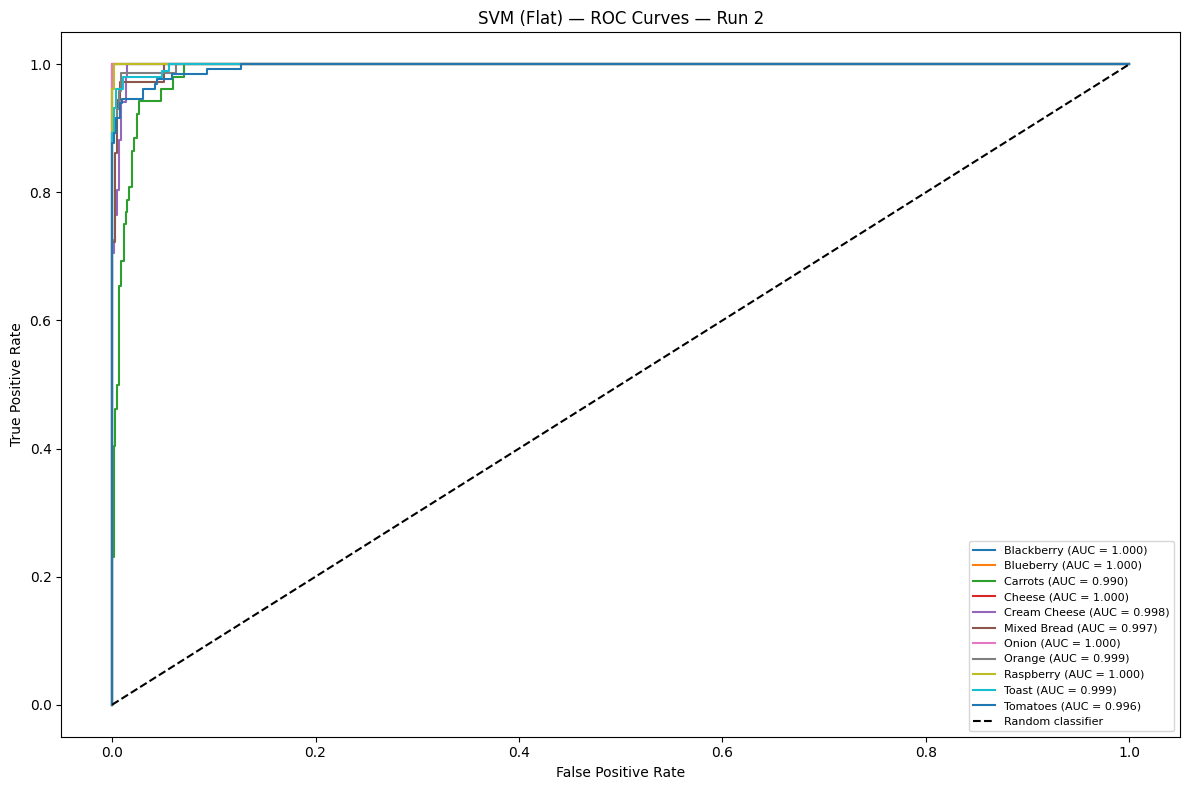

  Saved: D:\Mold Studies\Models\plots\svm_flat\svm_flat_roc_curves_run2.png


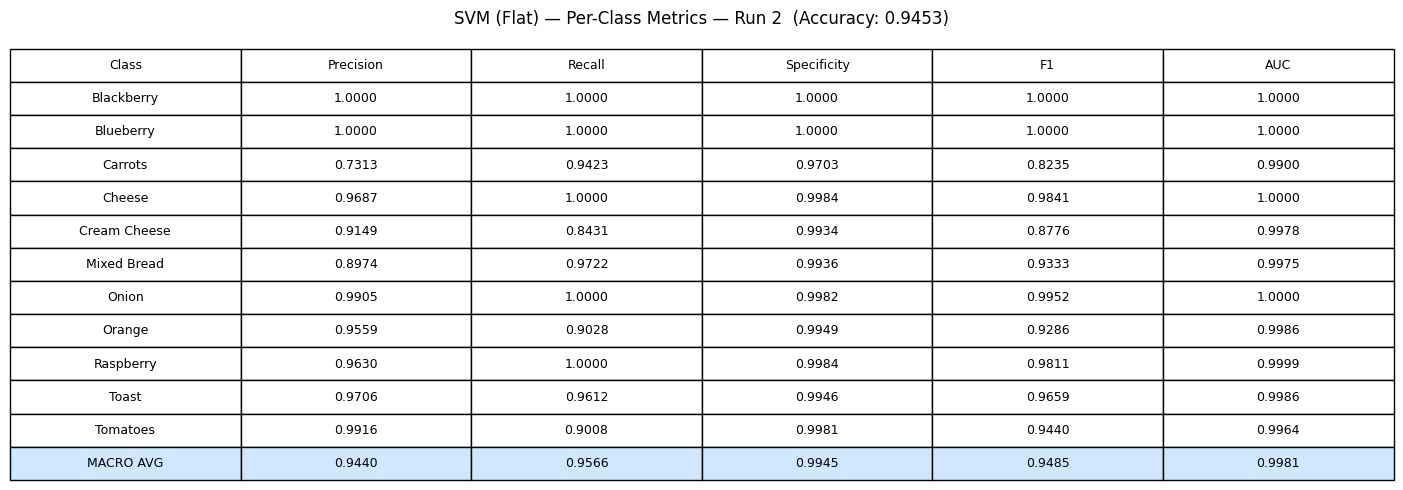

  Saved: D:\Mold Studies\Models\plots\svm_flat\svm_flat_metrics_table_run2.png

  RUN 3 / 5  —  SVM (Flattened Pixels)
  Seed : 99

  Training SVM...
  ✓ Training complete

  Run 3 Results
    Accuracy     : 0.9453
    Precision    : 0.9440
    Recall       : 0.9566
    Specificity  : 0.9945
    F1 Score     : 0.9485
    Mean AUC     : 0.9981


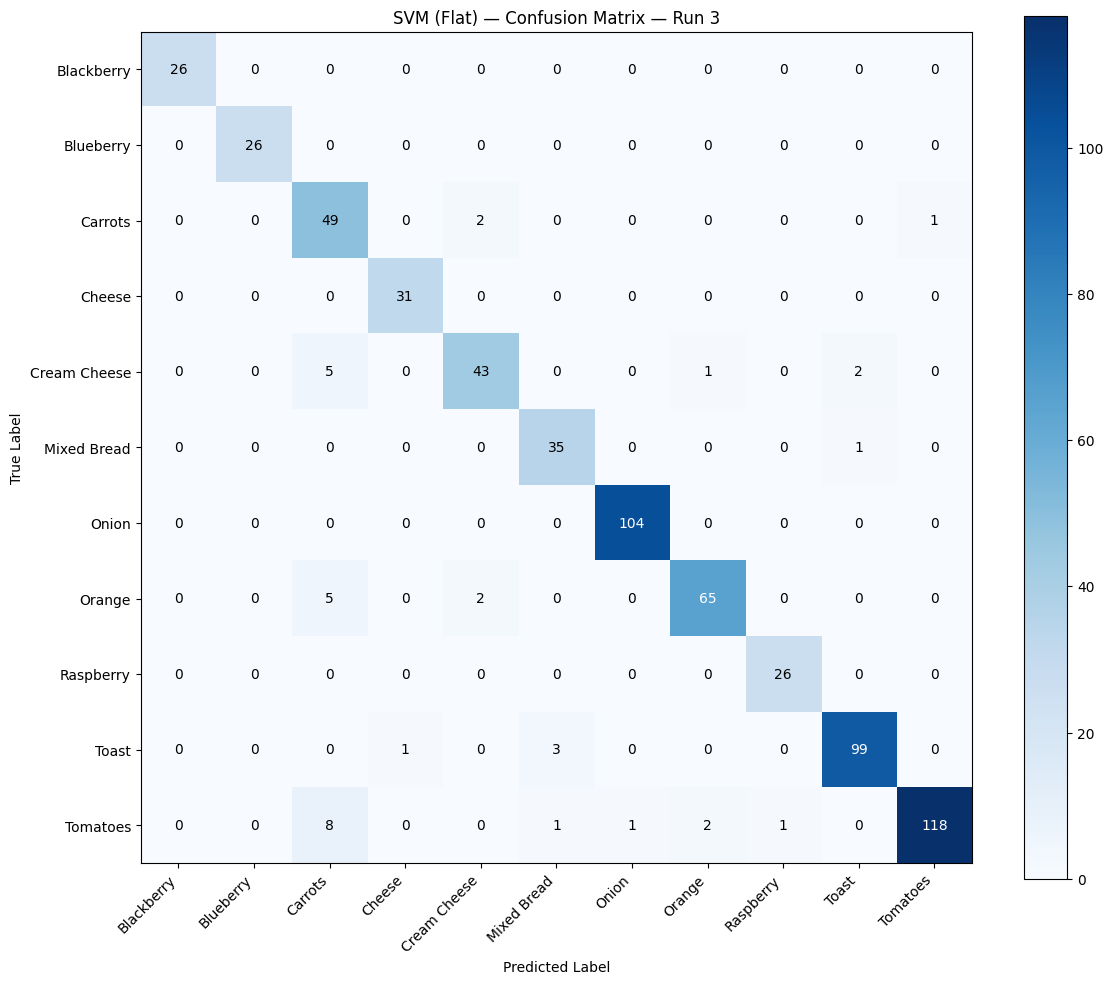

  Saved: D:\Mold Studies\Models\plots\svm_flat\svm_flat_confusion_matrix_run3.png


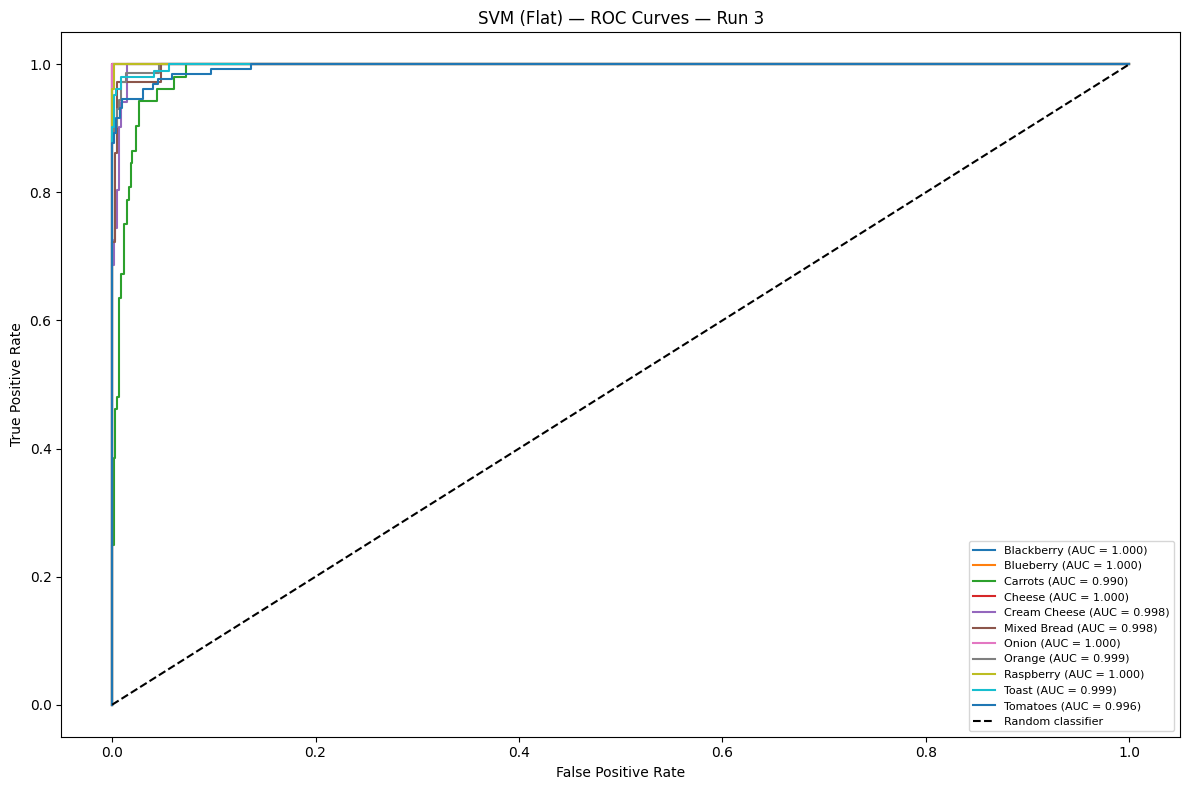

  Saved: D:\Mold Studies\Models\plots\svm_flat\svm_flat_roc_curves_run3.png


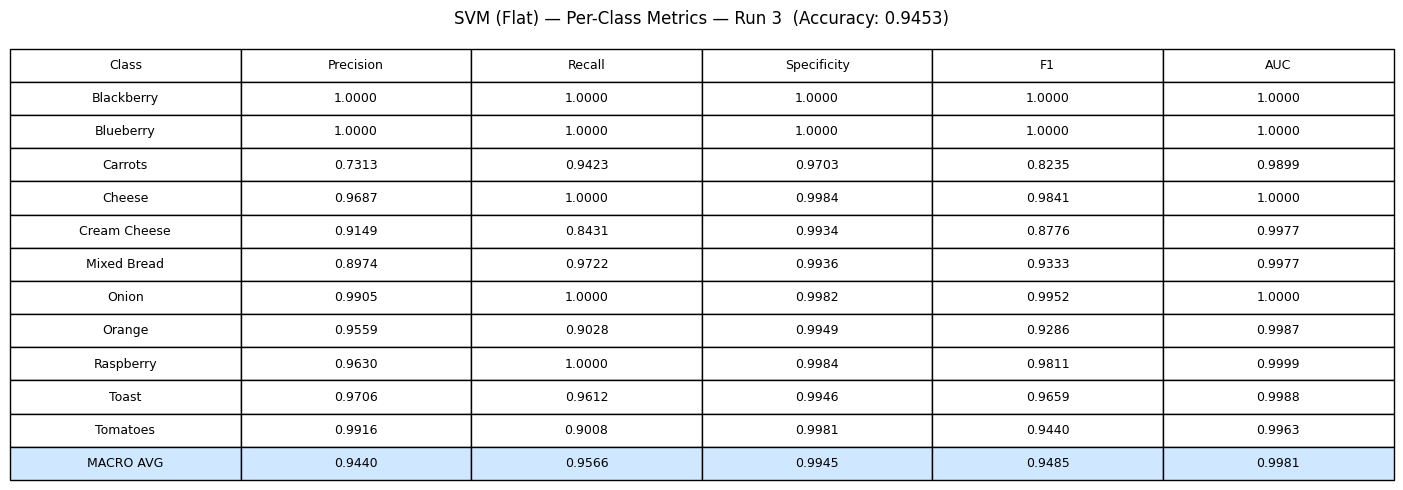

  Saved: D:\Mold Studies\Models\plots\svm_flat\svm_flat_metrics_table_run3.png

  RUN 4 / 5  —  SVM (Flattened Pixels)
  Seed : 123

  Training SVM...
  ✓ Training complete

  Run 4 Results
    Accuracy     : 0.9453
    Precision    : 0.9440
    Recall       : 0.9566
    Specificity  : 0.9945
    F1 Score     : 0.9485
    Mean AUC     : 0.9981


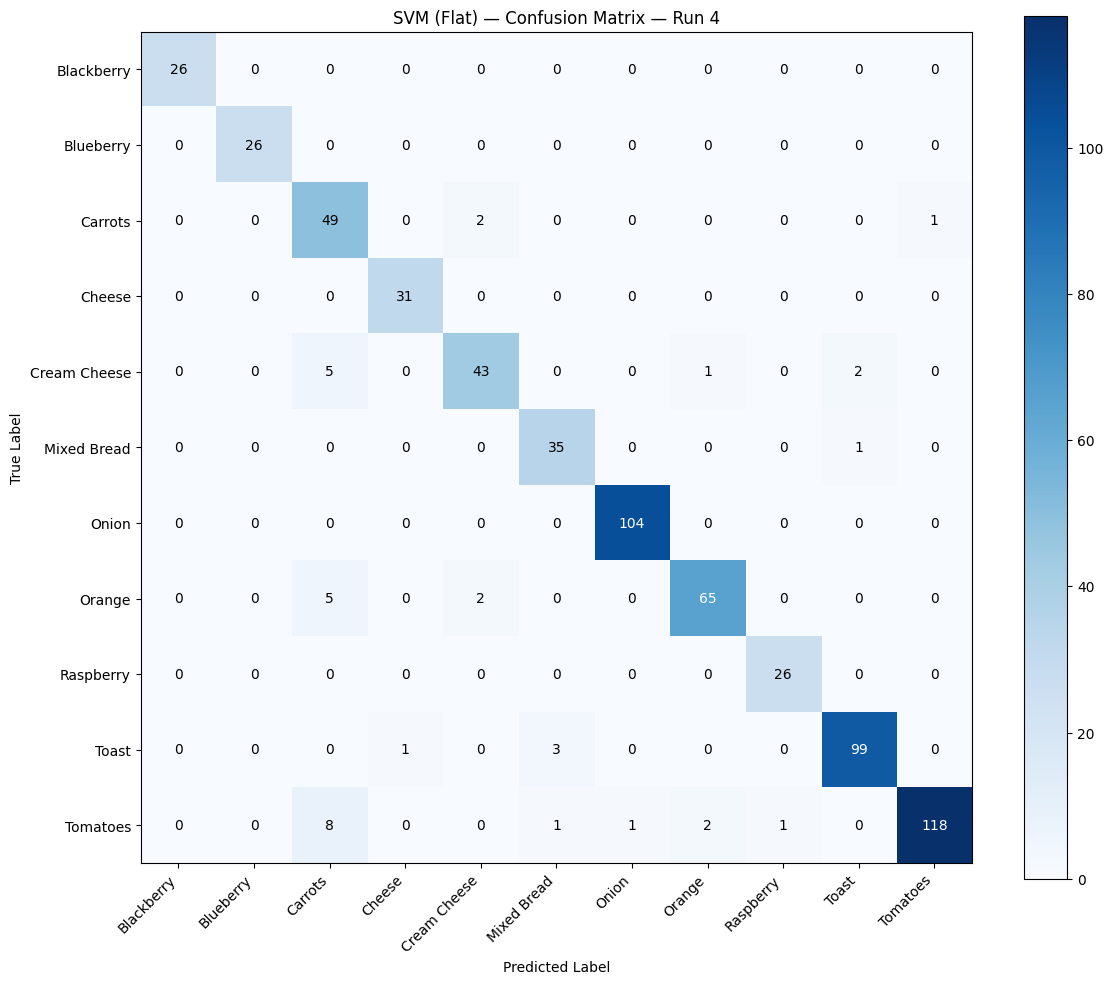

  Saved: D:\Mold Studies\Models\plots\svm_flat\svm_flat_confusion_matrix_run4.png


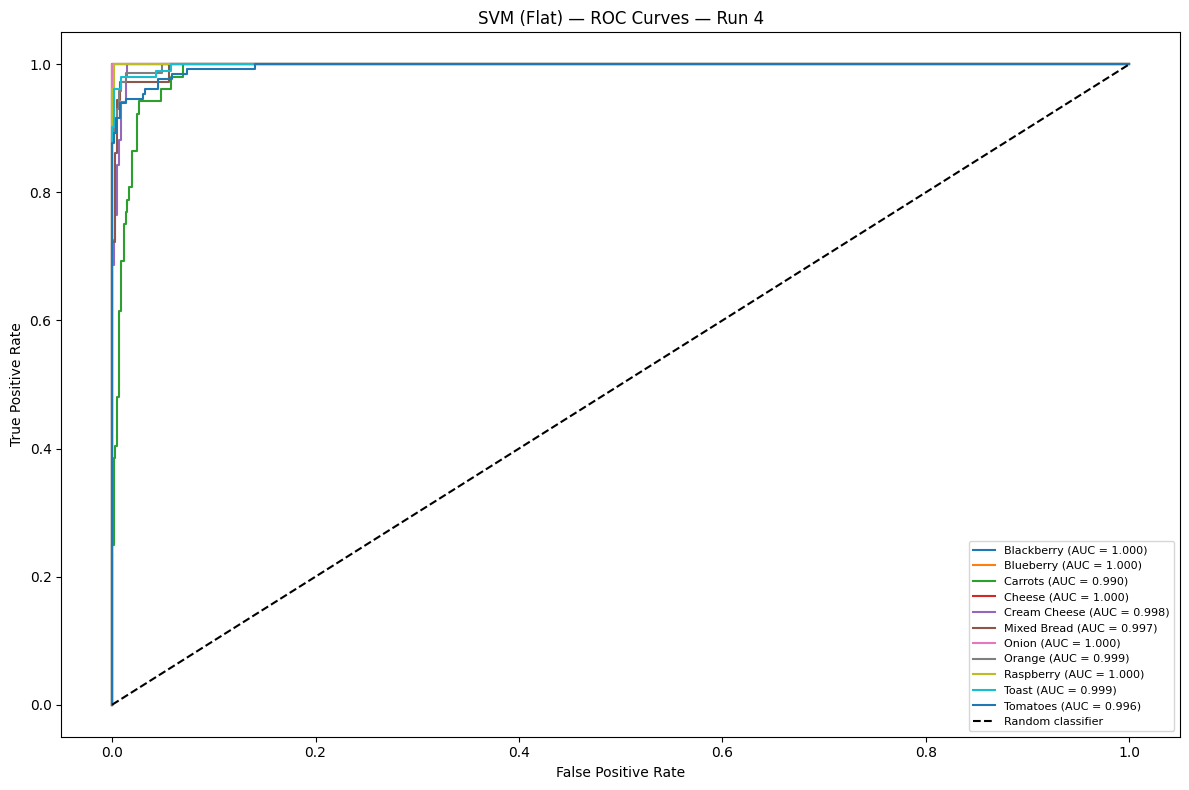

  Saved: D:\Mold Studies\Models\plots\svm_flat\svm_flat_roc_curves_run4.png


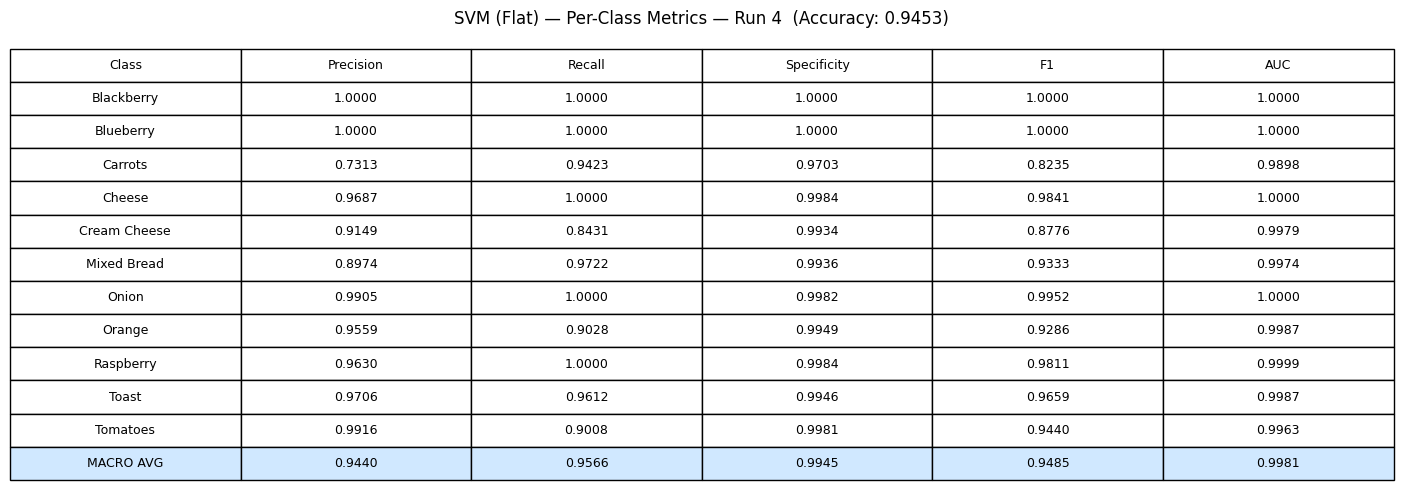

  Saved: D:\Mold Studies\Models\plots\svm_flat\svm_flat_metrics_table_run4.png

  RUN 5 / 5  —  SVM (Flattened Pixels)
  Seed : 256

  Training SVM...
  ✓ Training complete

  Run 5 Results
    Accuracy     : 0.9453
    Precision    : 0.9440
    Recall       : 0.9566
    Specificity  : 0.9945
    F1 Score     : 0.9485
    Mean AUC     : 0.9981


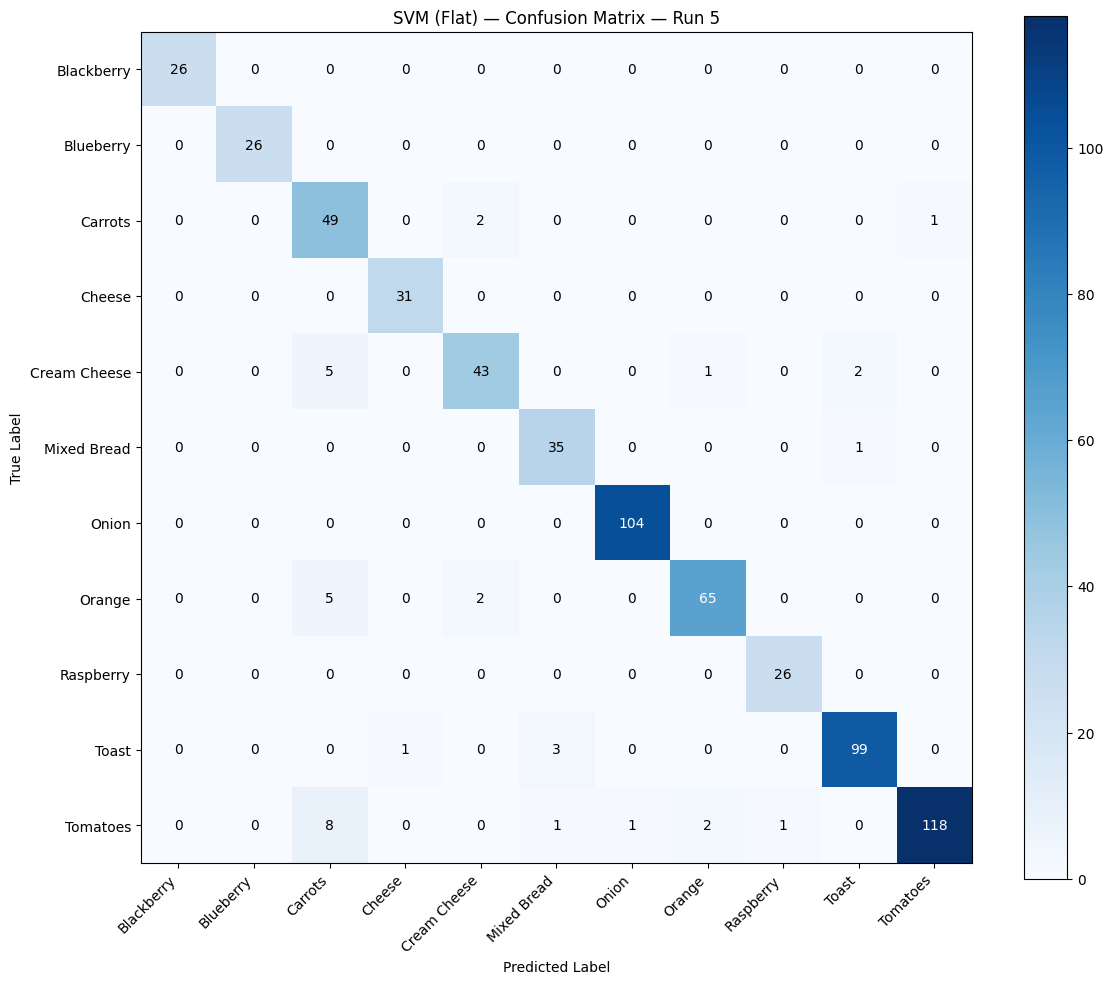

  Saved: D:\Mold Studies\Models\plots\svm_flat\svm_flat_confusion_matrix_run5.png


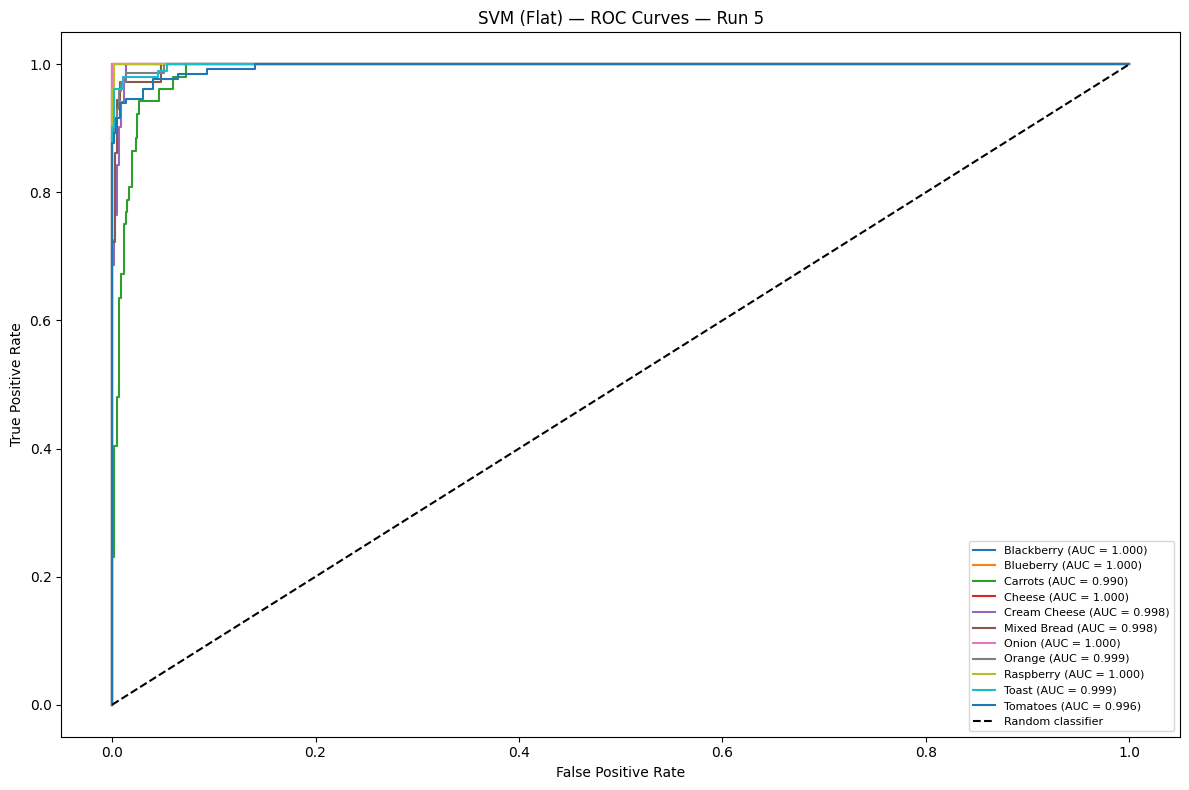

  Saved: D:\Mold Studies\Models\plots\svm_flat\svm_flat_roc_curves_run5.png


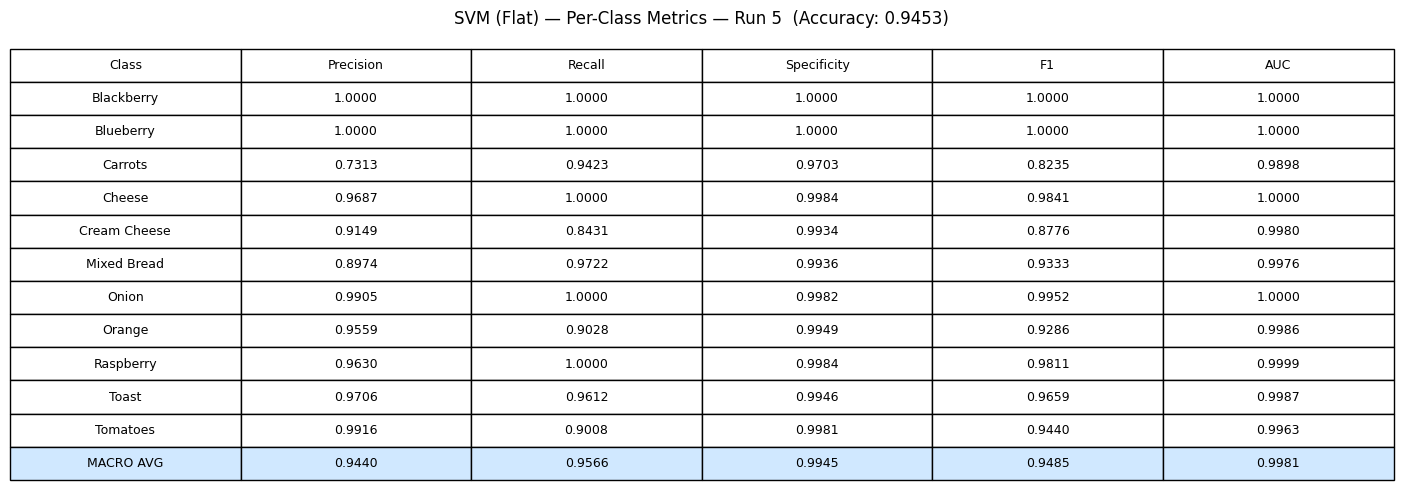

  Saved: D:\Mold Studies\Models\plots\svm_flat\svm_flat_metrics_table_run5.png

  PER-RUN RESULTS — SVM (Flattened Pixels)
  Run       Seed    Test Acc   Precision Sensitivity  F1 Score       AUC
──────────────────────────────────────────────────────────────────────────────
  1           27      0.9453      0.9440      0.9566    0.9485    0.9981
  2           42      0.9453      0.9440      0.9566    0.9485    0.9981
  3           99      0.9453      0.9440      0.9566    0.9485    0.9981
  4          123      0.9453      0.9440      0.9566    0.9485    0.9981
  5          256      0.9453      0.9440      0.9566    0.9485    0.9981
──────────────────────────────────────────────────────────────────────────────

──────────────────────────────  Statistical Summary  ──────────────────────────────
  Metric              Mean       Std       Min       Max              95% CI
──────────────────────────────────────────────────────────────────────────────
  Accuracy          0.9453    0.0000    

c:\Users\HomePC\miniconda3\envs\tf-cpu\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\HomePC\miniconda3\envs\tf-cpu\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


In [2]:
"""
Fragment 2 — SVM Training, 5-Run Statistical Analysis & Evaluation
===================================================================
SVM Mould/Fruit Multiclass Classification Pipeline

- Trains SVM 5 times using different random seeds
- Each run shuffles train data differently before fitting
- Computes full metrics per run on test set
- Computes confidence intervals across 5 runs
- Saves results for Fragment 3 cross-model comparison
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import scipy.stats as stats

# ── Configuration ─────────────────────────────────────────────────────────────

SAVE_DIR  = r"D:\Mold Studies\Models"
PLOT_DIR  = os.path.join(SAVE_DIR, "plots", "svm_flat")
TOTAL_RUNS = 5
SEEDS      = [27, 42, 99, 123, 256]   # one seed per run

os.makedirs(SAVE_DIR,  exist_ok=True)
os.makedirs(PLOT_DIR,  exist_ok=True)

# ── SVM Parameters ────────────────────────────────────────────────────────────

SVM_KERNEL = "linear"    # linear kernel is dramatically faster
SVM_C      = 1.0
SVM_GAMMA  = "scale"

# ── Step 1: Helper Functions ──────────────────────────────────────────────────

def compute_metrics(y_true, y_pred, y_prob):
    cm          = confusion_matrix(y_true, y_pred)
    accuracy    = accuracy_score(y_true, y_pred)
    precision   = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall      = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1          = f1_score(y_true, y_pred, average="macro", zero_division=0)

    # Specificity per class
    specificities = []
    for i in range(NUM_CLASSES):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - tp - fp - fn
        specificities.append(tn / (tn + fp + 1e-7))
    specificity = np.mean(specificities)

    # ROC / AUC
    y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    roc_auc    = {}
    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc[cls] = {
            "fpr": fpr,
            "tpr": tpr,
            "auc": auc(fpr, tpr)
        }

    return {
        "cm"         : cm,
        "accuracy"   : accuracy,
        "precision"  : precision,
        "recall"     : recall,
        "specificity": specificity,
        "f1"         : f1,
        "roc_auc"    : roc_auc,
    }


def plot_confusion_matrix(cm, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)

    ax.set(
        xticks      = np.arange(NUM_CLASSES),
        yticks      = np.arange(NUM_CLASSES),
        xticklabels = CLASS_NAMES,
        yticklabels = CLASS_NAMES,
        title       = f"SVM (Flat) — Confusion Matrix — Run {run_idx}",
        ylabel      = "True Label",
        xlabel      = "Predicted Label",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    thresh = cm.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(cm[i, j], "d"),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    path = os.path.join(save_dir, f"svm_flat_confusion_matrix_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"  Saved: {path}")


def plot_roc_curves(roc_auc, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(12, 8))

    for cls in CLASS_NAMES:
        ax.plot(
            roc_auc[cls]["fpr"],
            roc_auc[cls]["tpr"],
            label=f"{cls} (AUC = {roc_auc[cls]['auc']:.3f})"
        )

    ax.plot([0, 1], [0, 1], "k--", label="Random classifier")
    ax.set(
        title  = f"SVM (Flat) — ROC Curves — Run {run_idx}",
        xlabel = "False Positive Rate",
        ylabel = "True Positive Rate",
    )
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    path = os.path.join(save_dir, f"svm_flat_roc_curves_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"  Saved: {path}")


def plot_metrics_table(metrics, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.axis("off")

    rows = []
    for i, cls in enumerate(CLASS_NAMES):
        cm   = metrics["cm"]
        tp   = cm[i, i]
        fp   = cm[:, i].sum() - tp
        fn   = cm[i, :].sum() - tp
        tn   = cm.sum() - tp - fp - fn
        prec = tp / (tp + fp + 1e-7)
        rec  = tp / (tp + fn + 1e-7)
        spec = tn / (tn + fp + 1e-7)
        f1   = 2 * prec * rec / (prec + rec + 1e-7)
        rows.append([
            cls,
            f"{prec:.4f}",
            f"{rec:.4f}",
            f"{spec:.4f}",
            f"{f1:.4f}",
            f"{metrics['roc_auc'][cls]['auc']:.4f}",
        ])

    rows.append([
        "MACRO AVG",
        f"{metrics['precision']:.4f}",
        f"{metrics['recall']:.4f}",
        f"{metrics['specificity']:.4f}",
        f"{metrics['f1']:.4f}",
        f"{np.mean([metrics['roc_auc'][c]['auc'] for c in CLASS_NAMES]):.4f}",
    ])

    col_labels = ["Class", "Precision", "Recall",
                  "Specificity", "F1", "AUC"]

    table = ax.table(
        cellText  = rows,
        colLabels = col_labels,
        loc       = "center",
        cellLoc   = "center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.8)

    for j in range(len(col_labels)):
        table[len(rows), j].set_facecolor("#d0e8ff")

    ax.set_title(
        f"SVM (Flat) — Per-Class Metrics — Run {run_idx}  "
        f"(Accuracy: {metrics['accuracy']:.4f})",
        fontsize=12, pad=20
    )

    plt.tight_layout()
    path = os.path.join(save_dir, f"svm_flat_metrics_table_run{run_idx}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {path}")

# ── Step 2: 5-Run Training Loop ───────────────────────────────────────────────

print("=" * 60)
print("  Fragment 2 — SVM 5-Run Training")
print("=" * 60)
print(f"  Kernel       : {SVM_KERNEL}")
print(f"  C            : {SVM_C}")
print(f"  Gamma        : {SVM_GAMMA}")
print(f"  Seeds        : {SEEDS}")
print(f"  Features     : {X_train_raw.shape[1]}")
print("=" * 60)

all_metrics    = []
all_run_results = []

for run_idx, seed in enumerate(SEEDS, 1):

    print(f"\n{'='*60}")
    print(f"  RUN {run_idx} / {TOTAL_RUNS}  —  SVM (Flattened Pixels)")
    print(f"  Seed : {seed}")
    print(f"{'='*60}\n")

    # ── Shuffle train data with this run's seed ────────────────────────────────
    rng     = np.random.RandomState(seed)
    indices = rng.permutation(len(X_train_raw))
    X_tr    = X_train_raw[indices]
    y_tr    = y_train[indices]

    # ── Scale features ─────────────────────────────────────────────────────────
    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_test_raw)

    # ── Train SVM ──────────────────────────────────────────────────────────────
    print(f"  Training SVM...")
    svm = SVC(
        kernel      = SVM_KERNEL,
        C           = SVM_C,
        gamma       = SVM_GAMMA,
        probability = True,    # needed for ROC/AUC
        random_state= seed,
    )
    svm.fit(X_tr_sc, y_tr)
    print(f"  ✓ Training complete")

    # ── Evaluate on test set ───────────────────────────────────────────────────
    y_pred = svm.predict(X_te_sc)
    y_prob = svm.predict_proba(X_te_sc)

    metrics        = compute_metrics(y_test, y_pred, y_prob)
    metrics["run"] = run_idx
    metrics["seed"]= seed
    all_metrics.append(metrics)

    all_run_results.append({
        "run"        : run_idx,
        "seed"       : seed,
        "accuracy"   : metrics["accuracy"],
        "precision"  : metrics["precision"],
        "recall"     : metrics["recall"],
        "specificity": metrics["specificity"],
        "f1"         : metrics["f1"],
        "mean_auc"   : np.mean([metrics["roc_auc"][c]["auc"] for c in CLASS_NAMES]),
    })

    print(f"\n  Run {run_idx} Results")
    print(f"    Accuracy     : {metrics['accuracy']:.4f}")
    print(f"    Precision    : {metrics['precision']:.4f}")
    print(f"    Recall       : {metrics['recall']:.4f}")
    print(f"    Specificity  : {metrics['specificity']:.4f}")
    print(f"    F1 Score     : {metrics['f1']:.4f}")
    print(f"    Mean AUC     : "
          f"{np.mean([metrics['roc_auc'][c]['auc'] for c in CLASS_NAMES]):.4f}")

    plot_confusion_matrix(metrics["cm"],    run_idx, PLOT_DIR)
    plot_roc_curves(metrics["roc_auc"],     run_idx, PLOT_DIR)
    plot_metrics_table(metrics,             run_idx, PLOT_DIR)

# ── Step 3: Per-Run Summary Table ─────────────────────────────────────────────

col_run   = 6
col_seed  = 8
col_test  = 12
col_prec  = 12
col_sens  = 12
col_f1    = 10
col_auc   = 10

divider = "=" * (col_run + col_seed + col_test +
                 col_prec + col_sens + col_f1 + col_auc + 8)
thin    = "─" * (col_run + col_seed + col_test +
                 col_prec + col_sens + col_f1 + col_auc + 8)

print(f"\n{divider}")
print("  PER-RUN RESULTS — SVM (Flattened Pixels)")
print(divider)
print(
    f"  {'Run':<{col_run}}"
    f"{'Seed':>{col_seed}}"
    f"{'Test Acc':>{col_test}}"
    f"{'Precision':>{col_prec}}"
    f"{'Sensitivity':>{col_sens}}"
    f"{'F1 Score':>{col_f1}}"
    f"{'AUC':>{col_auc}}"
)
print(thin)

for r in all_run_results:
    print(
        f"  {r['run']:<{col_run}}"
        f"{r['seed']:>{col_seed}}"
        f"{r['accuracy']:>{col_test}.4f}"
        f"{r['precision']:>{col_prec}.4f}"
        f"{r['recall']:>{col_sens}.4f}"
        f"{r['f1']:>{col_f1}.4f}"
        f"{r['mean_auc']:>{col_auc}.4f}"
    )

print(thin)

# ── Step 4: Statistical Summary with Confidence Intervals ─────────────────────

print(f"\n{'─'*30}  Statistical Summary  {'─'*30}")
print(
    f"  {'Metric':<14}"
    f"{'Mean':>10}"
    f"{'Std':>10}"
    f"{'Min':>10}"
    f"{'Max':>10}"
    f"{'95% CI':>20}"
)
print(thin)

stat_metrics = {
    "Accuracy"   : [r["accuracy"]    for r in all_run_results],
    "Precision"  : [r["precision"]   for r in all_run_results],
    "Sensitivity": [r["recall"]      for r in all_run_results],
    "Specificity": [r["specificity"] for r in all_run_results],
    "F1 Score"   : [r["f1"]          for r in all_run_results],
    "AUC"        : [r["mean_auc"]    for r in all_run_results],
}

for label, vals in stat_metrics.items():
    vals    = np.array(vals)
    mean    = np.mean(vals)
    std     = np.std(vals)
    mn      = np.min(vals)
    mx      = np.max(vals)
    # 95% confidence interval using t-distribution (n=5)
    ci      = stats.t.interval(
                  0.95,
                  df    = len(vals) - 1,
                  loc   = mean,
                  scale = stats.sem(vals)
              )
    print(
        f"  {label:<14}"
        f"{mean:>10.4f}"
        f"{std:>10.4f}"
        f"{mn:>10.4f}"
        f"{mx:>10.4f}"
        f"  [{ci[0]:.4f}, {ci[1]:.4f}]"
    )

print(divider)

# ── Step 5: Expose for cross-model comparison ─────────────────────────────────

svm_flat_all_metrics     = all_metrics
svm_flat_all_run_results = all_run_results

print(f"\n  All plots saved to : {PLOT_DIR}")
print(f"\n  ✓ Fragment 2 complete.")
print(f"     svm_flat_all_metrics and svm_flat_all_run_results")
print(f"     are ready for Fragment 5 — Model Comparison.\n")